In [21]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [22]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

In [23]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [24]:
print(jax.default_backend())

gpu


In [25]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [26]:
t0, tfinal = 0.0, 0.5

In [27]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [28]:
def doublePendulum(w, t):
    
    x1, x2, x1_t, x2_t = w

    c = jnp.cos(x1 - x2)
    s = jnp.sin(x1 - x2)

    x1_tt = (m2*grav*jnp.sin(x2)*c - m2*s*(l1*x1_t**2*c + l2*x2_t**2) - (m1+m2)*grav*jnp.sin(x1))/ \
            (l1*(m1 + m2*s**2))
    
    x2_tt = ((m1+m2)*(l1*x1_t**2*s - grav*jnp.sin(x2) + grav*jnp.sin(x1)*c) + m2*l2*x2_t**2*s*c)/ \
            (l2*(m1 + m2*s**2))

    dwdt = [x1_t, x2_t, x1_tt, x2_tt]

    return dwdt

In [29]:
def doublePendulum_mom(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

In [30]:
@jax.jit
def calc_energy(x1, x2, x1t, x2t) :

    V = m1 * grav * (-l1 * jnp.cos(x1)) + m2 * grav * (-l1 * jnp.cos(x1) - l2 * jnp.cos(x2))
    K = 0.5 * m1 * (l1 * x1t)**2 + 0.5 * m2 * ((l1 * x1t)**2 + (l2 * x2t)**2 + 2 * l1 * l2 * x1t * x2t * jnp.cos(x1 - x2))

    E = V + K

    return E

In [31]:
# n = 500
# t = np.linspace(t0, tfinal, n)

# x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x1_t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x2_t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# y1_init = (m1 + m2)*l1**2*x1_t_init + m2*l1*l2*x2_t_init*np.cos(x1_init - x2_init)
# y2_init = m2*l2**2*x2_t_init + m2*l1*l2*x1_t_init*np.cos(x1_init - x2_init)
# H_init = (m2*l2**2*y1_init**2 + (m1+m2)*l1**2*y2_init**2 - 2*m2*l1*l2*y1_init*y2_init*jnp.cos(x1_init-x2_init))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1_init-x2_init)**2))-(m1+m2)*grav*l1*jnp.cos(x1_init)-m2*grav*l2*jnp.cos(x2_init)

# data_rk = np.column_stack([x1_init, x2_init, x1_t_init, x2_t_init])
# data_rk = np.reshape(data_rk, (-1,))
# t_rk = t

# data_rk_mom = np.column_stack([x1_init, x2_init, y1_init, y2_init])
# data_rk_mom = np.reshape(data_rk_mom, (-1,))
# t_rk_mom = t


# sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
# x1_rk, x2_rk, x1t_rk, x2t_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
# y1_rk = (m1 + m2)*l1**2*x1t_rk + m2*l1*l2*x2t_rk*np.cos(x1_rk - x2_rk)
# y2_rk = m2*l2**2*x2t_rk + m2*l1*l2*x1t_rk*np.cos(x1_rk - x2_rk)
# E_rk = calc_energy(x1_rk, x2_rk, x1t_rk, x2t_rk)

# sol_rk_mom = odeint(doublePendulum_mom, data_rk_mom, t_rk_mom, rtol = 1e-13, atol = 1e-13)
# x1_rk_mom, x2_rk_mom, y1_rk_mom, y2_rk_mom = sol_rk_mom[:, 0], sol_rk_mom[:, 1], sol_rk_mom[:, 2], sol_rk_mom[:, 3]

In [32]:
# fig = plt.figure(figsize=(12, 10))

# plt.subplot(1, 4, 1)
# plt.tight_layout()
# plt.plot(t, x1_rk, label = 'Vel RK')
# plt.plot(t, x1_rk_mom, label = 'Mom RK')
# plt.xlabel("x1")
# plt.grid()
# plt.legend()

# plt.subplot(1, 4, 2)
# plt.tight_layout()
# plt.plot(t, x2_rk, label = 'Vel RK')
# plt.plot(t, x2_rk_mom, label = 'Mom RK')
# plt.xlabel("x2")
# plt.grid()
# plt.legend()

# plt.subplot(1, 4, 3)
# plt.tight_layout()
# plt.plot(t, y1_rk, label = 'Vel RK')
# plt.plot(t, y1_rk_mom, label = 'Mom RK')
# plt.xlabel("y1")
# plt.grid()
# plt.legend()

# plt.subplot(1, 4, 4)
# plt.tight_layout()
# plt.plot(t, y2_rk, label = 'Vel RK')
# plt.plot(t, y2_rk_mom, label = 'Mom RK')
# plt.xlabel("y2")
# plt.grid()
# plt.legend()

In [33]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [34]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [35]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [36]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [37]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    x1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    x2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    x1ts = np.random.uniform(-1.0, 1.0, size=(N, 1))
    x2ts = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Es = calc_energy(x1s, x2s, x1ts, x2ts)

    ode_points = np.column_stack((ode_points, Es))
    zsensors = np.column_stack((x1s, x2s, x1ts, x2ts))
    
    return (ode_points, zsensors)

In [38]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 5000)
print(de_points.shape, zsensors.shape)

(5000, 2) (5000, 4)


In [39]:
E_vals = de_points[:, -1]
print(E_vals.shape)
Emax = np.max(E_vals)
Emin = np.min(E_vals)
print(Emin, Emax)

(5000,)
-29.401883902389702 -23.862305962793386


In [40]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tE.ndim == 1:
      tE = jnp.reshape(tE, (1,-1)) 

    t_0 = tE[:, :1]
    E_0 = tE[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
   
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    x1t_0 = u[:, 2:3]
    x2t_0 = u[:, 3:]

    # u = jnp.column_stack((x1_0, x2_0, x1t_0, x2t_0))

    b = t_0_norm

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_x1t = trunk_net[:, 2*self.units:3*self.units]
    trunk_x2t = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_x1t = branch_net[:, 2*self.units:3*self.units]
    branch_x2t = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    x1t = CombineBranches()(trunk_x1t, branch_x1t)
    x2t = CombineBranches()(trunk_x2t, branch_x2t)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    x1t = HardConstraint(self.t0, self.tfinal, x1t_0)([t_0, x1t])
    x2t = HardConstraint(self.t0, self.tfinal, x2t_0)([t_0, x2t])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    x1t = jnp.reshape(x1t, (-1,))
    x2t = jnp.reshape(x2t, (-1,))

    return x1, x2, x1t, x2t

In [41]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return Vdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(Vvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Vvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Vloss(params, tE, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    x1_tt_loss_w = 1.0
    x2_tt_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0

    t_0 = tE[:, 0]
    E_0 = tE[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    x1t_0 = z[:, 2]
    x2t_0 = z[:, 3]

    E_0 = calc_energy(x1_0, x2_0, x1t_0, x2t_0)

    x1 = Vvar(tE, z, 0, params)
    x2 = Vvar(tE, z, 1, params)
    x1t = Vvar(tE, z, 2, params)
    x2t = Vvar(tE, z, 3, params)

    dx1_t = Vvar_t(tE, z, 0, params)
    dx2_t = Vvar_t(tE, z, 1, params)
    dx1t_t = Vvar_t(tE, z, 2, params)
    dx2t_t = Vvar_t(tE, z, 3, params) 

    x1_t = dx1_t[:, 0]
    x2_t = dx2_t[:, 0]
    x1t_t = dx1t_t[:, 0]
    x2t_t = dx2t_t[:, 0]

    E = calc_energy(x1, x2, x1t, x2t)
  
    c = jnp.cos(x1 - x2)
    s = jnp.sin(x1 - x2)

    a1 = (l2 / l1) * (m2 / (m1 + m2)) * jnp.cos(x1 - x2)
    a2 = (l1 / l2) * jnp.cos(x1 - x2)
    f1 = -(l2 / l1) * (m2 / (m1 + m2)) * (x2t**2) * jnp.sin(x1 - x2) - (grav / l1) * jnp.sin(x1)
    f2 = (l1 / l2) * (x1t**2) * jnp.sin(x1 - x2) - (grav / l2) * jnp.sin(x2)
    g1 = (f1 - a1 * f2) / (1 - a1 * a2)
    g2 = (f2 - a2 * f1) / (1 - a1 * a2)

    loss1 = x1_t - x1t
    loss1 = jnp.mean(jnp.square(loss1))

    loss2 = x2_t - x2t
    loss2 = jnp.mean(jnp.square(loss2))

    loss3 = x1t_t - g1
    loss3 = jnp.mean(jnp.square(loss3))

    loss4 = x2t_t - g2
    loss4 = jnp.mean(jnp.square(loss4))

    E_loss = E_0 - E
    E_loss = jnp.mean(jnp.square(E_loss))

    diff_loss = loss1 + loss2 + loss3 + loss4

    total_loss = diff_loss + E_loss

    return total_loss, E_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    tE = pdes
    
    return jax.value_and_grad(Vloss, has_aux = True)(params, tE, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [42]:
def Vtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            losses, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses

            params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [43]:
Vdeeponet = VDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

Vparams = Vdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [44]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(Vparam_count)

19960


In [45]:
tree_info, shapes, Vparams_flat = flatten_pytree(Vparams)
Vparams_flat = jnp.load("V_t0.5_5000_5000_ep_DP.npy")
print(Vparams_flat.shape)
Vparams = reconstruct_pytree(tree_info, shapes, Vparams_flat)

(19960,)


In [46]:
# epochs = 5000
# Vparams, loss = Vtrain_network(Vparams, de_points, zsensors, epochs)

# plt.semilogy(loss)
# plt.grid()

In [47]:
# _, _, Vparams_flat = flatten_pytree(Vparams)
# jnp.save("V_t0.5_5000_5000_ep_DP", Vparams_flat)

In [48]:
# n = 500
# t = np.linspace(t0, tfinal, n)

# x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x1t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x2t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# E_init = calc_energy(x1_init, x2_init, x1t_init, x2t_init)

# x1x2x1tx2t_data = np.column_stack([x1_init, x2_init, x1t_init, x2t_init])
# x1x2x1tx2t_data = np.reshape(x1x2x1tx2t_data, (-1,))
# x1x2x1tx2t_data = np.repeat(np.expand_dims(x1x2x1tx2t_data, axis=0), n, axis=0)

# t_data = t
# E_data =  np.reshape(E_init, (-1,))
# E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
# tE_data = np.column_stack([t, E_data])

# x1 = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 0, Vparams)
# x2 = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 1, Vparams)
# x1t = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 2, Vparams)
# x2t = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 3, Vparams)
# E = calc_energy(x1, x2, x1t, x2t)

# t_rk = t
# x1x2x1tx2t_rk = np.column_stack([x1_init, x2_init, x1t_init, x2t_init])
# x1x2x1tx2t_rk = np.reshape(x1x2x1tx2t_rk, (-1,))

# sol_rk = odeint(doublePendulum, x1x2x1tx2t_rk, t_rk, rtol = 1e-13, atol = 1e-13)
# x1_rk, x2_rk, x1t_rk, x2t_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
# E_rk = calc_energy(x1_rk, x2_rk, x1t_rk, x2t_rk)

# fig = plt.figure(figsize=(12, 10))

# plt.subplot(1, 5, 1)
# plt.tight_layout()
# plt.plot(t, x1, label = 'Model')
# plt.plot(t, x1_rk, label = 'RK45')
# plt.xlabel("x1")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 2)
# plt.tight_layout()
# plt.plot(t, x2, label = 'Model')
# plt.plot(t, x2_rk, label = 'RK45')
# plt.xlabel("x2")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 3)
# plt.tight_layout()
# plt.plot(t, x1t, label = 'Model')
# plt.plot(t, x1t_rk, label = 'RK45')
# plt.xlabel("x1t")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 4)
# plt.tight_layout()
# plt.plot(t, x2t, label = 'Model')
# plt.plot(t, x2t_rk, label = 'RK45')
# plt.xlabel("x2t")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 5)
# plt.tight_layout()
# plt.plot(t, E, label = 'Model')
# plt.plot(t, E_rk, label = 'RK45')
# plt.xlabel("E")
# plt.grid()
# plt.legend()

In [49]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tE.ndim == 1:
      tE = jnp.reshape(tE, (1,-1)) 

    t_0 = tE[:, :1]
    E_0 = tE[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)
   
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    x1t_0 = u[:, 2:3]
    x2t_0 = u[:, 3:]

    b = jnp.column_stack((t_0_norm, E_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_x1t = trunk_net[:, 2*self.units:3*self.units]
    trunk_x2t = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_x1t = branch_net[:, 2*self.units:3*self.units]
    branch_x2t = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    x1t = CombineBranches()(trunk_x1t, branch_x1t)
    x2t = CombineBranches()(trunk_x2t, branch_x2t)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    x1t = HardConstraint(self.t0, self.tfinal, x1t_0)([t_0, x1t])
    x2t = HardConstraint(self.t0, self.tfinal, x2t_0)([t_0, x2t])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    x1t = jnp.reshape(x1t, (-1,))
    x2t = jnp.reshape(x2t, (-1,))

    return x1, x2, x1t, x2t

In [50]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t_temp(t, z, component, params):
  return jax.grad(var_model, 0)(t, z, component, params)[0]

@partial(jax.jit, static_argnums=(2,))
def var_tt(t, z, component, params):
    return jax.vmap(jax.grad(var_t_temp, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tE, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    x1_tt_loss_w = 1.0
    x2_tt_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0

    t_0 = tE[:, 0]
    E_0 = tE[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    x1t_0 = z[:, 2]
    x2t_0 = z[:, 3]

    E_0 = calc_energy(x1_0, x2_0, x1t_0, x2t_0)

    x1 = var(tE, z, 0, params)
    x2 = var(tE, z, 1, params)
    x1t = var(tE, z, 2, params)
    x2t = var(tE, z, 3, params)

    dx1_t = var_t(tE, z, 0, params)
    dx2_t = var_t(tE, z, 1, params)
    dx1t_t = var_t(tE, z, 2, params)
    dx2t_t = var_t(tE, z, 3, params)

    dx1_tt = var_tt(tE, z, 0, params)
    dx2_tt = var_tt(tE, z, 1, params)
    dx1t_tt = var_tt(tE, z, 2, params)
    dx2t_tt = var_tt(tE, z, 3, params)

    x1_t = dx1_t[:, 0]
    x2_t = dx2_t[:, 0]
    x1t_t = dx1t_t[:, 0]
    x2t_t = dx2t_t[:, 0]
    
    E = calc_energy(x1, x2, x1t, x2t)
  
    c = jnp.cos(x1 - x2)
    s = jnp.sin(x1 - x2)

    a1 = (l2 / l1) * (m2 / (m1 + m2)) * jnp.cos(x1 - x2)
    a2 = (l1 / l2) * jnp.cos(x1 - x2)
    f1 = -(l2 / l1) * (m2 / (m1 + m2)) * (x2t**2) * jnp.sin(x1 - x2) - (grav / l1) * jnp.sin(x1)
    f2 = (l1 / l2) * (x1t**2) * jnp.sin(x1 - x2) - (grav / l2) * jnp.sin(x2)
    g1 = (f1 - a1 * f2) / (1 - a1 * a2)
    g2 = (f2 - a2 * f1) / (1 - a1 * a2)

    loss1 = x1_t - x1t
    loss1 = jnp.mean(jnp.square(loss1))

    loss2 = x2_t - x2t
    loss2 = jnp.mean(jnp.square(loss2))

    loss3 = x1t_t - g1
    loss3 = jnp.mean(jnp.square(loss3))

    loss4 = x2t_t - g2
    loss4 = jnp.mean(jnp.square(loss4))

    E_loss = E_0 - E
    E_loss = jnp.mean(jnp.square(E_loss))

    diff_loss = loss1 + loss2 + loss3 + loss4

    total_loss = diff_loss + E_loss

    return total_loss, E_loss

@jax.jit
def train_step(params, pdes, z):
    tE = pdes
    
    return jax.value_and_grad(loss, has_aux = True)(params, tE, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [51]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            losses, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses

            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [52]:
deeponet = DeepONet(t0, tfinal, Emin, Emax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [53]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

20000


In [54]:
tree_info, shapes, params_flat = flatten_pytree(params)
params_flat = jnp.load("P_t0.5_5000_5000_ep_DP.npy")
print(params_flat.shape)
params = reconstruct_pytree(tree_info, shapes, params_flat)

(20000,)


In [55]:
# epochs = 5000
# params, loss = train_network(params, de_points, zsensors, epochs)

# plt.semilogy(loss)
# plt.grid()

In [56]:
# _, _, params_flat = flatten_pytree(params)
# jnp.save("P_t0.5_5000_5000_ep_DP", params_flat)

In [57]:
@jax.jit
def gradD_fun(x, E_0) :

    x1 = x[0]
    x2 = x[1]
    x1t = x[2]
    x2t = x[3]
    E = calc_energy(x1, x2, x1t, x2t)
    
    dE_dx1 = m1*grav*l1*jnp.sin(x1) + m2*grav*l1*jnp.sin(x1) - m2*l1*l2*x1t*x2t*jnp.sin(x1-x2)
    dE_dx2 = m2*grav*l2*jnp.sin(x2) + m2*l1*l2*x1t*x2t*jnp.sin(x1-x2)  
    dE_dx1t = m1*(l1**2)*x1t + m2*(l1**2)*x1t + m2*l1*l2*x2t*jnp.cos(x1-x2)
    dE_dx2t = m2*(l2**2)*x2t +  m2*l1*l2*x1t*jnp.cos(x1-x2)

    dD_dx1 = 2*(E - E_0)*dE_dx1
    dD_dx2 = 2*(E - E_0)*dE_dx2
    dD_dx1t = 2*(E - E_0)*dE_dx1t
    dD_dx2t = 2*(E - E_0)*dE_dx2t

    deriv_D_arr = jnp.array([dD_dx1, dD_dx2, dD_dx1t, dD_dx2t])

    return deriv_D_arr

In [58]:
@jax.jit
def D_fun(x, E_0) :

    x1 = x[0]
    x2 = x[1]
    x1t = x[2]
    x2t = x[3]
        
    V = m1 * grav * (-l1 * jnp.cos(x1)) + m2 * grav * (-l1 * jnp.cos(x1) - l2 * jnp.cos(x2))
    K = 0.5 * m1 * (l1 * x1t)**2 + 0.5 * m2 * ((l1 * x1t)**2 + (l2 * x2t)**2 + 2 * l1 * l2 * x1t * x2t * jnp.cos(x1 - x2))

    E = V + K
    
    D = (E - E_0)**2

    D_arr = jnp.array([D])

    return D_arr

In [59]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    
    return 1/x

In [60]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, iter = args

    c1 = 1e-4

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)

    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
    
    return final_bool

In [61]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = D_fun(next_x, E_0)
    next_grad = gradD_fun(next_x, E_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, iter)


In [62]:
@jax.jit
def BFGS(x, E_0) :

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    I_4 = jnp.identity(4, dtype = jnp.float64)
    B_0_inv = jnp.identity(4, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    D_0 = D_fun(x_0, E_0)
    gradD_0 = gradD_fun(x_0, E_0)

    p = -(B_0_inv@gradD_0)

    pot_x = x_0 + alpha*p
    pot_D = D_fun(pot_x, E_0)
    pot_gradD = gradD_fun(pot_x, E_0)

    init_args = (alpha, x_0, D_0, gradD_0, pot_x, pot_D, pot_gradD, p, E_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p


    while iter_num < 5:

        delta_x = x_1 - x_0

        D_1 = D_fun(x_1, E_0)
        gradD_1 = gradD_fun(x_1, E_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_4 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_4 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        pot_x = x_1 + alpha*p
        pot_D = D_fun(pot_x, E_0)
        pot_gradD = gradD_fun(pot_x, E_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, pot_x, pot_D, pot_gradD, p, E_0, init_iter)

        step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_temp = x_1 + step*p

        x_0 = x_1
        x_1 = x_temp

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    x1 = x_1[0]
    x2 = x_1[1]
    x1t = x_1[2]
    x2t = x_1[3]

    x1 = jnp.reshape(x1, (-1,))[0]
    x2 = jnp.reshape(x2, (-1,))[0]
    x1t = jnp.reshape(x1t, (-1,))[0]
    x2t = jnp.reshape(x2t, (-1,))[0]

    return x_1

In [63]:
@jax.jit
def find_min_bfgs(x, E_0) :

    return jax.vmap(BFGS, (0, 0), 0)(x, E_0)

In [64]:
class ClosestPoint(nn.Module):

    E_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        z_min = find_min_bfgs(inputs, self.E_0)
    
        return z_min

In [65]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tE.ndim == 1:
      tE = jnp.reshape(tE, (1,-1))  

      
    t_0 = tE[:, :1]
    E_0 = tE[:, 1:]

    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)

    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    x1t_0 = u[:, 2:3]
    x2t_0 = u[:, 3:]

    b = jnp.column_stack((t_0_norm, E_0_norm)) 

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_x1t = trunk_net[:, 2*self.units:3*self.units]
    trunk_x2t = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_x1t = branch_net[:, 2*self.units:3*self.units]
    branch_x2t = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    x1t = CombineBranches()(trunk_x1t, branch_x1t)
    x2t = CombineBranches()(trunk_x2t, branch_x2t)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    x1t = HardConstraint(self.t0, self.tfinal, x1t_0)([t_0, x1t])
    x2t = HardConstraint(self.t0, self.tfinal, x2t_0)([t_0, x2t])

    z = jnp.column_stack([x1, x2, x1t, x2t])
    z = ClosestPoint(E_0)(z)   

    x1 = z[:, :1]
    x2 = z[:, 1:2]
    x1t = z[:, 2:3]
    x2t = z[:, 3:]

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    x1t = jnp.reshape(x1t, (-1,))
    x2t = jnp.reshape(x2t, (-1,))


    return x1, x2, x1t, x2t

In [66]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t_temp(t, z, component, params):
  return jax.grad(var_model, 0)(t, z, component, params)[0]

@partial(jax.jit, static_argnums=(2,))
def var_tt(t, z, component, params):
    return jax.vmap(jax.grad(var_t_temp, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, tE, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    x1_tt_loss_w = 1.0
    x2_tt_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0

    t_0 = tE[:, 0]
    E_0 = tE[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    x1t_0 = z[:, 2]
    x2t_0 = z[:, 3]

    E_0 = calc_energy(x1_0, x2_0, x1t_0, x2t_0)

    x1 = var(tE, z, 0, params)
    x2 = var(tE, z, 1, params)
    x1t = var(tE, z, 2, params)
    x2t = var(tE, z, 3, params)

    dx1_t = var_t(tE, z, 0, params)
    dx2_t = var_t(tE, z, 1, params)
    dx1t_t = var_t(tE, z, 2, params)
    dx2t_t = var_t(tE, z, 3, params)

    dx1_tt = var_tt(tE, z, 0, params)
    dx2_tt = var_tt(tE, z, 1, params)
    dx1t_tt = var_tt(tE, z, 2, params)
    dx2t_tt = var_tt(tE, z, 3, params)

    x1_t = dx1_t[:, 0]
    x2_t = dx2_t[:, 0]
    x1t_t = dx1t_t[:, 0]
    x2t_t = dx2t_t[:, 0]

    x1_tt = dx1_tt[:, 0]
    x2_tt = dx2_tt[:, 0]
    x1t_tt = dx1t_tt[:, 0]
    x2t_tt = dx2t_tt[:, 0]
    
    E = calc_energy(x1, x2, x1t, x2t)
  
    c = jnp.cos(x1 - x2)
    s = jnp.sin(x1 - x2)

    a1 = (l2 / l1) * (m2 / (m1 + m2)) * jnp.cos(x1 - x2)
    a2 = (l1 / l2) * jnp.cos(x1 - x2)
    f1 = -(l2 / l1) * (m2 / (m1 + m2)) * (x2t**2) * jnp.sin(x1 - x2) - (grav / l1) * jnp.sin(x1)
    f2 = (l1 / l2) * (x1t**2) * jnp.sin(x1 - x2) - (grav / l2) * jnp.sin(x2)
    g1 = (f1 - a1 * f2) / (1 - a1 * a2)
    g2 = (f2 - a2 * f1) / (1 - a1 * a2)


    extraloss1 = x1_tt - x1t_t
    extraloss1 = jnp.mean(jnp.square(extraloss1))

    extraloss2 = x2_tt - x2t_t
    extraloss2 = jnp.mean(jnp.square(extraloss2))

    extraloss = extraloss1 + extraloss2
    
    loss1 = x1_t - x1t
    loss1 = jnp.mean(jnp.square(loss1))

    loss2 = x2_t - x2t
    loss2 = jnp.mean(jnp.square(loss2))

    loss3 = x1t_t - g1
    loss3 = jnp.mean(jnp.square(loss3))

    loss4 = x2t_t - g2
    loss4 = jnp.mean(jnp.square(loss4))

    E_loss = E_0 - E
    E_loss = jnp.mean(jnp.square(E_loss))

    diff_loss = loss1 + loss2 + loss3 + loss4

    total_loss = diff_loss + extraloss

    return total_loss, extraloss

@jax.jit
def Ctrain_step(params, pdes, z):
    tE = pdes
    
    return jax.value_and_grad(Closs, has_aux = True)(params, tE, z)


@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [67]:
def Ctrain_network(params, des, sensors, epochs=100):

    m_max = 1.0
    
    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)
    
    for i in range(epochs):

        # print(i)

        batch_no = 0
    
        for (des_batch, z_batch) in ds:
    
            losses, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses

            # tree_info, shapes, grads_flat = flatten_pytree(grads)

            # # print(grads_flat)
            # m = jnp.linalg.norm(grads_flat)
            # # print(m)
            # if m >= m_max :
            #     grads_flat = (m_max*grads_flat)/m
            # # print(grads_flat)
            # # input()
            
            # grads = reconstruct_pytree(tree_info, shapes, grads_flat)
            
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss
            

            batch_no = batch_no + 1

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [68]:
Cdeeponet = CDeepONet(t0, tfinal, Emin, Emax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 4), 1.0, dtype = jnp.float64 )

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [69]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

20000


In [101]:
Cparams = copy.deepcopy(params)

In [102]:
@jax.jit
def loss_fun(params, t, z):

    final_loss, imp_loss = Closs(params, t, z)
    
    return final_loss


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun, has_aux = False)(params, t, z)


@jax.jit
def loss_fun_aux(params, t, z):

    final_loss, aux_loss = Closs(params, t, z)
    
    return final_loss, aux_loss

In [103]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [104]:
@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.1
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        # cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        # cond = jnp.logical_and(cond1, cond2)
        cond = cond1

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [105]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s
    

In [106]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes
    
    # losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        # losses.append(loss_fun(paramsn, t, z))
     
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    loss, aux_loss = loss_fun_aux(paramsn, t, z)

    return paramsn, (loss, aux_loss)

In [151]:
def ctrain_network_lbfgs(params, des, zsensor, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches

    print("batch size:", batch_size)
    
    ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):
      
        print(i)
        # batch_no = 0
      
        for (des_batch, z_batch) in ds:

          # print("batch", batch_no)
          # batch_no = batch_no + 1  
        
          params, losses = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 5)
          loss, aux_loss = losses
            
          epoch_loss[i] += loss
          epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 1 == 0:
            
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {aux_loss}')

    return params, epoch_loss

In [152]:
print(de_points.shape, zsensors.shape)

(5000, 2) (5000, 4)


In [153]:
tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)
Cparams_flat = jnp.load("C_t0.5_5000_10000_ep_DP.npy")
print(Cparams_flat.shape)
Cparams = reconstruct_pytree(tree_info, shapes, Cparams_flat)

(20000,)


In [156]:
epochs = 50
Cparams, loss_lbfgs = ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

batch size: 500
0
Loss in epoch 0: 6.08722976627621e-05
Aux Loss in epoch 0: 0.0008012376089775594
1
Loss in epoch 1: 4.173691646716321e-05
Aux Loss in epoch 1: 0.0005601933413987194
2
Loss in epoch 2: 3.719073833685773e-05
Aux Loss in epoch 2: 0.000447910056828569
3
Loss in epoch 3: 3.5568017509394897e-05
Aux Loss in epoch 3: 0.0004312887643001986
4
Loss in epoch 4: 3.4308201194010675e-05
Aux Loss in epoch 4: 0.00044347551946179837
5
Loss in epoch 5: 3.351066015050755e-05
Aux Loss in epoch 5: 0.00036861625838736407
6
Loss in epoch 6: 3.296953344972869e-05
Aux Loss in epoch 6: 0.0002895919057157919
7
Loss in epoch 7: 3.2381765000827334e-05
Aux Loss in epoch 7: 0.0003104817859936813
8
Loss in epoch 8: 3.2146779422220314e-05
Aux Loss in epoch 8: 0.00037291054717333405
9
Loss in epoch 9: 3.124190817159547e-05
Aux Loss in epoch 9: 0.00034528528024525547
10
Loss in epoch 10: 3.1191122159926163e-05
Aux Loss in epoch 10: 0.0003595384727426683
11
Loss in epoch 11: 3.0831382569427245e-05
Aux Lo

In [157]:
# epochs = 4000
# Cparams, loss_lbfgs = Ctrain_network(Cparams, de_points, zsensors, epochs)

In [158]:
# plt.semilogy(loss_lbfgs)
# plt.grid()
# total_loss = np.concatenate((loss_adam, loss_lbfgs))
# plt.semilogy(total_loss)
# plt.grid()

In [159]:
# _, _, Cparams_flat = flatten_pytree(Cparams)
# jnp.save("C_t0.5_5000_10000_ep_DP", Cparams_flat)

In [160]:
def set_vals(list) :

    x1_val = np.array(list[0], dtype = np.float64)
    x2_val = np.array(list[1], dtype = np.float64)
    x1t_val = np.array(list[2], dtype = np.float64)
    x2t_val = np.array(list[3], dtype = np.float64)
    E_val = calc_energy(x1_val, x2_val, x1t_val, x2t_val)

    return x1_val, x2_val, x1t_val, x2t_val, E_val

In [161]:
def init_preds(n) :

    return np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)

In [162]:
def prep_train(t_data, x1, x2, x1t, x2t, E, model, params, n) :

    E_data = np.repeat(np.expand_dims(E, axis=0), n, axis=0)
    tE_data = np.column_stack([t_data, E_data])
   
    x1x2x1tx2t_data = np.column_stack([x1, x2, x1t, x2t])
    x1x2x1tx2t_data = np.reshape(x1x2x1tx2t_data, (-1,))
    x1x2x1tx2t_data = np.repeat(np.expand_dims(x1x2x1tx2t_data, axis=0), n, axis=0)

    x1 = jax.vmap(model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 0, params)
    x2 = jax.vmap(model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 1, params)
    x1t = jax.vmap(model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 2, params)
    x2t = jax.vmap(model, [0, 0, None, None])(tE_data, x1x2x1tx2t_data, 3, params)
    E = calc_energy(x1, x2, x1t, x2t)
    
    return x1, x2, x1t, x2t, E, tE_data, x1x2x1tx2t_data

In [173]:
#Empty

0.001 20000 40


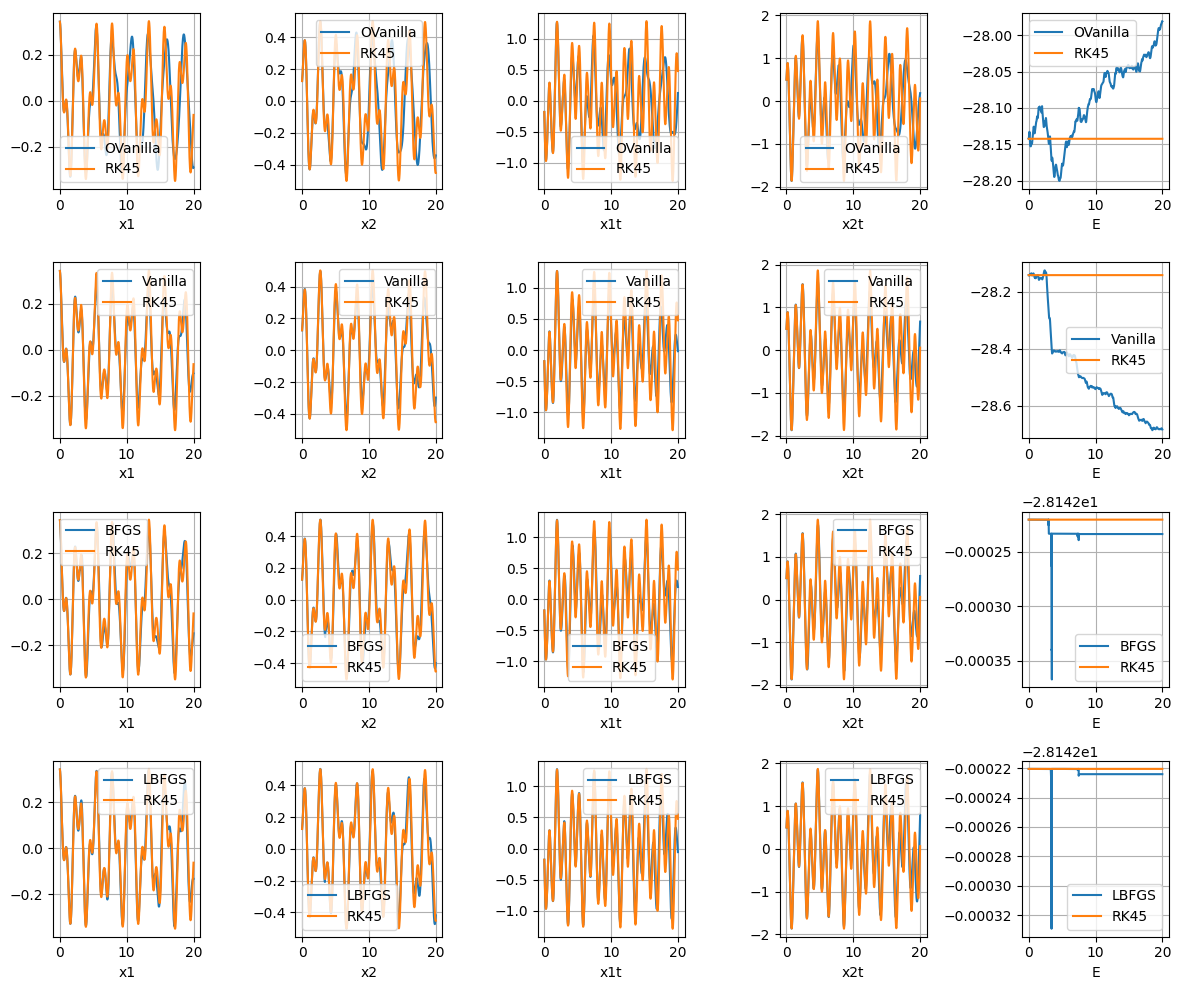

In [174]:
n = 500

t_start = 0.0
t_end = 20.0

n_ts = int(n*(t_end/tfinal))

t_step = t_end/n_ts

num_cycles = math.ceil(n_ts/n)
print(t_step, n_ts, num_cycles)

t_ts = np.linspace(t_start, t_end, n_ts)

x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x1t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
E_init = calc_energy(x1_init, x2_init, x1t_init, x2t_init)

x1x2x1tx2t_rk = np.column_stack([x1_init, x2_init, x1t_init, x2t_init])
x1x2x1tx2t_rk = np.reshape(x1x2x1tx2t_rk, (-1,))
t_rk = t_ts

sol_rk = odeint(doublePendulum, x1x2x1tx2t_rk, t_rk, rtol = 1e-13, atol = 1e-13)
x1_rk, x2_rk, x1t_rk, x2t_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
E_rk = calc_energy(x1_rk, x2_rk, x1t_rk, x2t_rk)


x1_pred_ovan, x2_pred_ovan, x1t_pred_ovan, x2t_pred_ovan, E_pred_ovan = init_preds(n_ts)

x1_pred_van, x2_pred_van, x1t_pred_van, x2t_pred_van, E_pred_van = init_preds(n_ts)

x1_pred_bfgs, x2_pred_bfgs, x1t_pred_bfgs, x2t_pred_bfgs, E_pred_bfgs = init_preds(n_ts)

x1_pred_lbfgs, x2_pred_lbfgs, x1t_pred_lbfgs, x2t_pred_lbfgs, E_pred_lbfgs = init_preds(n_ts)

x1_data_ovan, x1_data_van, x1_data_bfgs, x1_data_lbfgs = x1_init, x1_init, x1_init, x1_init
x2_data_ovan, x2_data_van, x2_data_bfgs, x2_data_lbfgs = x2_init, x2_init, x2_init, x2_init
x1t_data_ovan, x1t_data_van, x1t_data_bfgs, x1t_data_lbfgs = x1t_init, x1t_init, x1t_init, x1t_init
x2t_data_ovan, x2t_data_van, x2t_data_bfgs, x2t_data_lbfgs = x2t_init, x2t_init, x2t_init, x2t_init
E_data_ovan, E_data_van, E_data_bfgs, E_data_lbfgs = E_init, E_init, E_init, E_init

t_data = np.linspace(t0, tfinal, n)
t_data_sub = np.linspace(t0 + t_step, tfinal, n)

for i in range(num_cycles) :

    if i != 0 :
        t_data = t_data_sub

    x1_ovan, x2_ovan, x1t_ovan, x2t_ovan, E_ovan, _, _ = prep_train(t_data, 
                                                   x1_data_ovan, x2_data_ovan, x1t_data_ovan, x2t_data_ovan, E_data_ovan, 
                                                   Vvar_model, Vparams, n)    

    x1_van, x2_van, x1t_van, x2t_van, E_van, _, _ = prep_train(t_data, 
                                                   x1_data_van, x2_data_van, x1t_data_van, x2t_data_van, E_data_van, 
                                                   var_model, params, n)

    x1_bfgs, x2_bfgs, x1t_bfgs, x2t_bfgs, E_bfgs, _, _ = prep_train(t_data, 
                                                   x1_data_bfgs, x2_data_bfgs, x1t_data_bfgs, x2t_data_bfgs, E_data_bfgs, 
                                                   Cvar_model, params, n)  
    
    x1_lbfgs, x2_lbfgs, x1t_lbfgs, x2t_lbfgs, E_lbfgs, _, _ = prep_train(t_data, 
                                                   x1_data_lbfgs, x2_data_lbfgs, x1t_data_lbfgs, x2t_data_lbfgs, E_data_lbfgs, 
                                                   Cvar_model, Cparams, n)    

    x1_pred_ovan[i*n:(i+1)*n] = x1_ovan
    x2_pred_ovan[i*n:(i+1)*n] = x2_ovan
    x1t_pred_ovan[i*n:(i+1)*n] = x1t_ovan
    x2t_pred_ovan[i*n:(i+1)*n] = x2t_ovan
    E_pred_ovan[i*n:(i+1)*n] = E_ovan

    x1_pred_van[i*n:(i+1)*n] = x1_van
    x2_pred_van[i*n:(i+1)*n] = x2_van
    x1t_pred_van[i*n:(i+1)*n] = x1t_van
    x2t_pred_van[i*n:(i+1)*n] = x2t_van
    E_pred_van[i*n:(i+1)*n] = E_van
    
    x1_pred_bfgs[i*n:(i+1)*n] = x1_bfgs
    x2_pred_bfgs[i*n:(i+1)*n] = x2_bfgs
    x1t_pred_bfgs[i*n:(i+1)*n] = x1t_bfgs
    x2t_pred_bfgs[i*n:(i+1)*n] = x2t_bfgs
    E_pred_bfgs[i*n:(i+1)*n] = E_bfgs
    
    x1_pred_lbfgs[i*n:(i+1)*n] = x1_lbfgs
    x2_pred_lbfgs[i*n:(i+1)*n] = x2_lbfgs
    x1t_pred_lbfgs[i*n:(i+1)*n] = x1t_lbfgs
    x2t_pred_lbfgs[i*n:(i+1)*n] = x2t_lbfgs
    E_pred_lbfgs[i*n:(i+1)*n] = E_lbfgs

    x1_data_ovan = x1_pred_ovan[(i+1)*n - 1]
    x2_data_ovan = x2_pred_ovan[(i+1)*n - 1]
    x1t_data_ovan = x1t_pred_ovan[(i+1)*n - 1]
    x2t_data_ovan = x2t_pred_ovan[(i+1)*n - 1]
    E_data_ovan = E_pred_ovan[(i+1)*n - 1]
 
    x1_data_van = x1_pred_van[(i+1)*n - 1]
    x2_data_van = x2_pred_van[(i+1)*n - 1]
    x1t_data_van = x1t_pred_van[(i+1)*n - 1]
    x2t_data_van = x2t_pred_van[(i+1)*n - 1]
    E_data_van = E_pred_van[(i+1)*n - 1]

    x1_data_bfgs = x1_pred_bfgs[(i+1)*n - 1]
    x2_data_bfgs = x2_pred_bfgs[(i+1)*n - 1]
    x1t_data_bfgs = x1t_pred_bfgs[(i+1)*n - 1]
    x2t_data_bfgs = x2t_pred_bfgs[(i+1)*n - 1]
    E_data_bfgs = E_pred_bfgs[(i+1)*n - 1]
    
    x1_data_lbfgs = x1_pred_lbfgs[(i+1)*n - 1]
    x2_data_lbfgs = x2_pred_lbfgs[(i+1)*n - 1]
    x1t_data_lbfgs = x1t_pred_lbfgs[(i+1)*n - 1]
    x2t_data_lbfgs = x2t_pred_lbfgs[(i+1)*n - 1]
    E_data_lbfgs = E_pred_lbfgs[(i+1)*n - 1]


fig = plt.figure(figsize=(12, 10))

plt.subplot(4, 5, 1)
plt.tight_layout()
plt.plot(t_ts, x1_pred_ovan)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 2)
plt.tight_layout()
plt.plot(t_ts, x2_pred_ovan)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 3)
plt.tight_layout()
plt.plot(t_ts, x1t_pred_ovan)
plt.plot(t_ts, x1t_rk)
plt.xlabel("x1t")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 4)
plt.tight_layout()
plt.plot(t_ts, x2t_pred_ovan)
plt.plot(t_ts, x2t_rk)
plt.xlabel("x2t")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 5)
plt.tight_layout()
plt.plot(t_ts, E_pred_ovan)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 6)
plt.tight_layout()
plt.plot(t_ts, x1_pred_van)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 7)
plt.tight_layout()
plt.plot(t_ts, x2_pred_van)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 8)
plt.tight_layout()
plt.plot(t_ts, x1t_pred_van)
plt.plot(t_ts, x1t_rk)
plt.xlabel("x1t")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 9)
plt.tight_layout()
plt.plot(t_ts, x2t_pred_van)
plt.plot(t_ts, x2t_rk)
plt.xlabel("x2t")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 10)
plt.tight_layout()
plt.plot(t_ts, E_pred_van)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 11)
plt.tight_layout()
plt.plot(t_ts, x1_pred_bfgs)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 12)
plt.tight_layout()
plt.plot(t_ts, x2_pred_bfgs)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 13)
plt.tight_layout()
plt.plot(t_ts, x1t_pred_bfgs)
plt.plot(t_ts, x1t_rk)
plt.xlabel("x1t")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 14)
plt.tight_layout()
plt.plot(t_ts, x2t_pred_bfgs)
plt.plot(t_ts, x2t_rk)
plt.xlabel("x2t")
plt.grid()
plt.legend(['BFGS','RK45'])


plt.subplot(4, 5, 15)
plt.tight_layout()
plt.plot(t_ts, E_pred_bfgs)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 16)
plt.tight_layout()
plt.plot(t_ts, x1_pred_lbfgs)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 17)
plt.tight_layout()
plt.plot(t_ts, x2_pred_lbfgs)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 18)
plt.tight_layout()
plt.plot(t_ts, x1t_pred_lbfgs)
plt.plot(t_ts, x1t_rk)
plt.xlabel("x1t")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 19)
plt.tight_layout()
plt.plot(t_ts, x2t_pred_lbfgs)
plt.plot(t_ts, x2t_rk)
plt.xlabel("x2t")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 20)
plt.tight_layout()
plt.plot(t_ts, E_pred_lbfgs)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['LBFGS','RK45'])

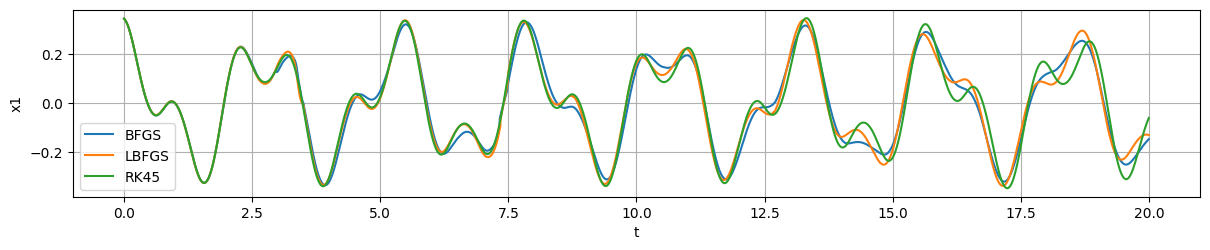

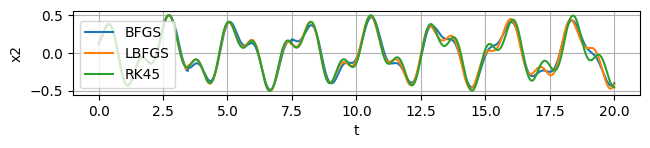

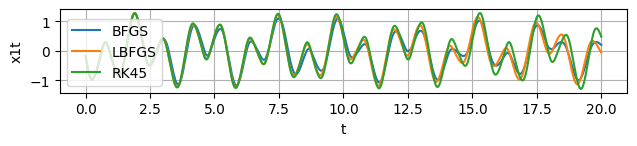

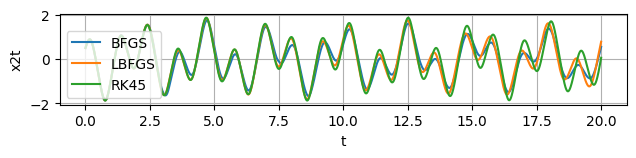

In [175]:
fig = plt.figure(figsize=(12, 9))

plt.subplot(4, 1, 1)
plt.tight_layout()
#plt.plot(t_ts, x1_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, x1_pred_van, label = 'Vanilla')
plt.plot(t_ts, x1_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, x1_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, x1_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("x1")
plt.grid()
plt.legend()
plt.show()

plt.subplot(4, 1, 2)
plt.tight_layout()
#plt.plot(t_ts, x2_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, x2_pred_van, label = 'Vanilla')
plt.plot(t_ts, x2_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, x2_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, x2_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

plt.subplot(4, 1, 3)
plt.tight_layout()
#plt.plot(t_ts, x1t_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, x1t_pred_van, label = 'Vanilla')
plt.plot(t_ts, x1t_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, x1t_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, x1t_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("x1t")
plt.grid()
plt.legend()
plt.show()

plt.subplot(4, 1, 4)
plt.tight_layout()
#plt.plot(t_ts, x2t_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, x2t_pred_van, label = 'Vanilla')
plt.plot(t_ts, x2t_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, x2t_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, x2t_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("x2t")
plt.grid()
plt.legend()
plt.show()

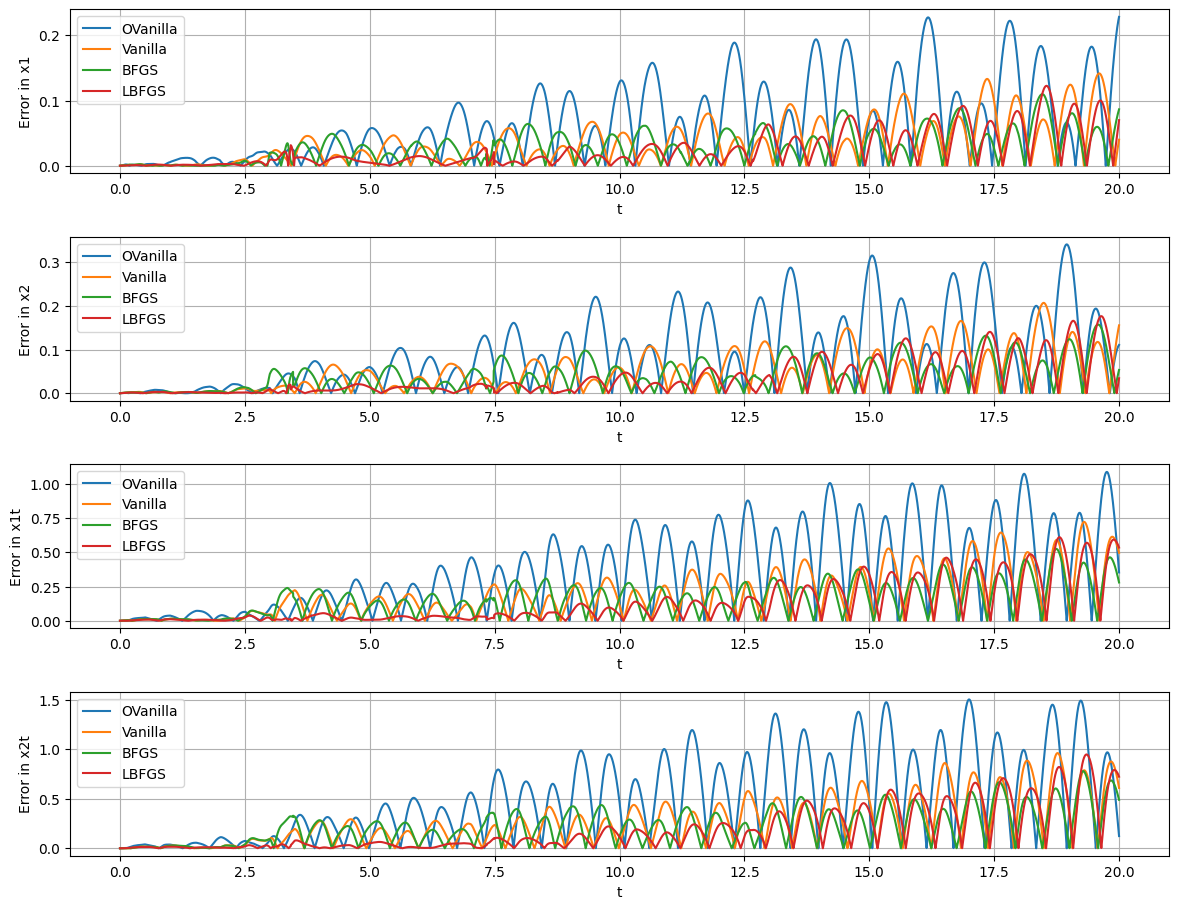

In [176]:
fig = plt.figure(figsize=(12, 9))

plt.subplot(4, 1, 1)
plt.tight_layout()
plt.plot(t_ts, abs(x1_pred_ovan - x1_rk), label = 'OVanilla')
plt.plot(t_ts, abs(x1_pred_van - x1_rk), label = 'Vanilla')
plt.plot(t_ts, abs(x1_pred_bfgs - x1_rk), label = 'BFGS')
plt.plot(t_ts, abs(x1_pred_lbfgs - x1_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in x1")
plt.grid()
plt.legend()

plt.subplot(4, 1, 2)
plt.tight_layout()
plt.plot(t_ts, abs(x2_pred_ovan - x2_rk), label = 'OVanilla')
plt.plot(t_ts, abs(x2_pred_van - x2_rk), label = 'Vanilla')
plt.plot(t_ts, abs(x2_pred_bfgs - x2_rk), label = 'BFGS')
plt.plot(t_ts, abs(x2_pred_lbfgs - x2_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in x2")
plt.grid()
plt.legend()

plt.subplot(4, 1, 3)
plt.tight_layout()
plt.plot(t_ts, abs(x1t_pred_ovan - x1t_rk), label = 'OVanilla')
plt.plot(t_ts, abs(x1t_pred_van - x1t_rk), label = 'Vanilla')
plt.plot(t_ts, abs(x1t_pred_bfgs - x1t_rk), label = 'BFGS')
plt.plot(t_ts, abs(x1t_pred_lbfgs - x1t_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in x1t")
plt.grid()
plt.legend()


plt.subplot(4, 1, 4)
plt.tight_layout()
plt.plot(t_ts, abs(x2t_pred_ovan - x2t_rk), label = 'OVanilla')
plt.plot(t_ts, abs(x2t_pred_van - x2t_rk), label = 'Vanilla')
plt.plot(t_ts, abs(x2t_pred_bfgs - x2t_rk), label = 'BFGS')
plt.plot(t_ts, abs(x2t_pred_lbfgs - x2t_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in x2t")
plt.grid()
plt.legend()

In [171]:
def compare_methods(num_trials, t_end_val) :

    n = 500
    trials_num = [i+1 for i in range(num_trials)]
    
    t_start = 0.0
    t_end = t_end_val
    
    n_ts = int(n*(t_end/tfinal))
    
    t_step = t_end/n_ts
    
    num_cycles = math.ceil(n_ts/n)
    
    t_ts = np.linspace(t_start, t_end, n_ts)
 
    x1_errors_bfgs, x2_errors_bfgs, x1t_errors_bfgs, x2t_errors_bfgs = [], [], [], []
    x1_errors_lbfgs, x2_errors_lbfgs, x1t_errors_lbfgs, x2t_errors_lbfgs = [], [], [], []
    
    for i in range(num_trials) :

        print("Trial no", i + 1)

        x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        x1t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        x2t_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        E_init = calc_energy(x1_init, x2_init, x1t_init, x2t_init)
        
        x1x2x1tx2t_rk = np.column_stack([x1_init, x2_init, x1t_init, x2t_init])
        x1x2x1tx2t_rk = np.reshape(x1x2x1tx2t_rk, (-1,))
        t_rk = t_ts
        
        sol_rk = odeint(doublePendulum, x1x2x1tx2t_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1_rk, x2_rk, x1t_rk, x2t_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
        E_rk = calc_energy(x1_rk, x2_rk, x1t_rk, x2t_rk)
        
        
        x1_pred_ovan, x2_pred_ovan, x1t_pred_ovan, x2t_pred_ovan, E_pred_ovan = init_preds(n_ts)
        
        x1_pred_van, x2_pred_van, x1t_pred_van, x2t_pred_van, E_pred_van = init_preds(n_ts)
        
        x1_pred_bfgs, x2_pred_bfgs, x1t_pred_bfgs, x2t_pred_bfgs, E_pred_bfgs = init_preds(n_ts)
        
        x1_pred_lbfgs, x2_pred_lbfgs, x1t_pred_lbfgs, x2t_pred_lbfgs, E_pred_lbfgs = init_preds(n_ts)
        
        x1_data_ovan, x1_data_van, x1_data_bfgs, x1_data_lbfgs = x1_init, x1_init, x1_init, x1_init
        x2_data_ovan, x2_data_van, x2_data_bfgs, x2_data_lbfgs = x2_init, x2_init, x2_init, x2_init
        x1t_data_ovan, x1t_data_van, x1t_data_bfgs, x1t_data_lbfgs = x1t_init, x1t_init, x1t_init, x1t_init
        x2t_data_ovan, x2t_data_van, x2t_data_bfgs, x2t_data_lbfgs = x2t_init, x2t_init, x2t_init, x2t_init
        E_data_ovan, E_data_van, E_data_bfgs, E_data_lbfgs = E_init, E_init, E_init, E_init
        
        t_data = np.linspace(t0, tfinal, n)
        t_data_sub = np.linspace(t0 + t_step, tfinal, n)
        
        for i in range(num_cycles) :
        
            if i != 0 :
                t_data = t_data_sub
        
            x1_ovan, x2_ovan, x1t_ovan, x2t_ovan, E_ovan, _, _ = prep_train(t_data, 
                                                           x1_data_ovan, x2_data_ovan, x1t_data_ovan, x2t_data_ovan, E_data_ovan, 
                                                           Vvar_model, Vparams, n)    
        
            x1_van, x2_van, x1t_van, x2t_van, E_van, _, _ = prep_train(t_data, 
                                                           x1_data_van, x2_data_van, x1t_data_van, x2t_data_van, E_data_van, 
                                                           var_model, params, n)
        
            x1_bfgs, x2_bfgs, x1t_bfgs, x2t_bfgs, E_bfgs, _, _ = prep_train(t_data, 
                                                           x1_data_bfgs, x2_data_bfgs, x1t_data_bfgs, x2t_data_bfgs, E_data_bfgs, 
                                                           Cvar_model, params, n)  
            
            x1_lbfgs, x2_lbfgs, x1t_lbfgs, x2t_lbfgs, E_lbfgs, _, _ = prep_train(t_data, 
                                                           x1_data_lbfgs, x2_data_lbfgs, x1t_data_lbfgs, x2t_data_lbfgs, E_data_lbfgs, 
                                                           Cvar_model, Cparams, n)    
        
            x1_pred_ovan[i*n:(i+1)*n] = x1_ovan
            x2_pred_ovan[i*n:(i+1)*n] = x2_ovan
            x1t_pred_ovan[i*n:(i+1)*n] = x1t_ovan
            x2t_pred_ovan[i*n:(i+1)*n] = x2t_ovan
            E_pred_ovan[i*n:(i+1)*n] = E_ovan
        
            x1_pred_van[i*n:(i+1)*n] = x1_van
            x2_pred_van[i*n:(i+1)*n] = x2_van
            x1t_pred_van[i*n:(i+1)*n] = x1t_van
            x2t_pred_van[i*n:(i+1)*n] = x2t_van
            E_pred_van[i*n:(i+1)*n] = E_van
            
            x1_pred_bfgs[i*n:(i+1)*n] = x1_bfgs
            x2_pred_bfgs[i*n:(i+1)*n] = x2_bfgs
            x1t_pred_bfgs[i*n:(i+1)*n] = x1t_bfgs
            x2t_pred_bfgs[i*n:(i+1)*n] = x2t_bfgs
            E_pred_bfgs[i*n:(i+1)*n] = E_bfgs
            
            x1_pred_lbfgs[i*n:(i+1)*n] = x1_lbfgs
            x2_pred_lbfgs[i*n:(i+1)*n] = x2_lbfgs
            x1t_pred_lbfgs[i*n:(i+1)*n] = x1t_lbfgs
            x2t_pred_lbfgs[i*n:(i+1)*n] = x2t_lbfgs
            E_pred_lbfgs[i*n:(i+1)*n] = E_lbfgs
        
            x1_data_ovan = x1_pred_ovan[(i+1)*n - 1]
            x2_data_ovan = x2_pred_ovan[(i+1)*n - 1]
            x1t_data_ovan = x1t_pred_ovan[(i+1)*n - 1]
            x2t_data_ovan = x2t_pred_ovan[(i+1)*n - 1]
            E_data_ovan = E_pred_ovan[(i+1)*n - 1]
         
            x1_data_van = x1_pred_van[(i+1)*n - 1]
            x2_data_van = x2_pred_van[(i+1)*n - 1]
            x1t_data_van = x1t_pred_van[(i+1)*n - 1]
            x2t_data_van = x2t_pred_van[(i+1)*n - 1]
            E_data_van = E_pred_van[(i+1)*n - 1]
        
            x1_data_bfgs = x1_pred_bfgs[(i+1)*n - 1]
            x2_data_bfgs = x2_pred_bfgs[(i+1)*n - 1]
            x1t_data_bfgs = x1t_pred_bfgs[(i+1)*n - 1]
            x2t_data_bfgs = x2t_pred_bfgs[(i+1)*n - 1]
            E_data_bfgs = E_pred_bfgs[(i+1)*n - 1]
            
            x1_data_lbfgs = x1_pred_lbfgs[(i+1)*n - 1]
            x2_data_lbfgs = x2_pred_lbfgs[(i+1)*n - 1]
            x1t_data_lbfgs = x1t_pred_lbfgs[(i+1)*n - 1]
            x2t_data_lbfgs = x2t_pred_lbfgs[(i+1)*n - 1]
            E_data_lbfgs = E_pred_lbfgs[(i+1)*n - 1]


        x1_err_bfgs = np.mean(np.abs(x1_pred_bfgs - x1_rk))
        x2_err_bfgs = np.mean(np.abs(x2_pred_bfgs - x2_rk))
        x1t_err_bfgs = np.mean(np.abs(x1t_pred_bfgs - x1t_rk))
        x2t_err_bfgs = np.mean(np.abs(x2t_pred_bfgs - x2t_rk))

        x1_err_lbfgs = np.mean(np.abs(x1_pred_lbfgs - x1_rk))
        x2_err_lbfgs = np.mean(np.abs(x2_pred_lbfgs - x2_rk))
        x1t_err_lbfgs = np.mean(np.abs(x1t_pred_lbfgs - x1t_rk))
        x2t_err_lbfgs = np.mean(np.abs(x2t_pred_lbfgs - x2t_rk))

        x1_errors_bfgs.append(x1_err_bfgs)
        x2_errors_bfgs.append(x2_err_bfgs)
        x1t_errors_bfgs.append(x1t_err_bfgs)
        x2t_errors_bfgs.append(x2t_err_bfgs)

        x1_errors_lbfgs.append(x1_err_lbfgs)
        x2_errors_lbfgs.append(x2_err_lbfgs)
        x1t_errors_lbfgs.append(x1t_err_lbfgs)
        x2t_errors_lbfgs.append(x2t_err_lbfgs)

    
    fig = plt.figure(figsize=(12, 9))
    
    plt.subplot(4, 1, 1)
    plt.tight_layout()
    plt.plot(trials_num, x1_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, x1_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in x1")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 1, 2)
    plt.tight_layout()
    plt.plot(trials_num, x2_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, x2_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in x2")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.subplot(4, 1, 3)
    plt.tight_layout()
    plt.plot(trials_num, x1t_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, x1t_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in x1t")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()

    plt.subplot(4, 1, 4)
    plt.tight_layout()
    plt.plot(trials_num, x2t_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, x2t_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in x2t")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()

    
    plt.show()
    
    return 

Trial no 1
Trial no 2
Trial no 3
Trial no 4
Trial no 5
Trial no 6
Trial no 7
Trial no 8
Trial no 9
Trial no 10
Trial no 11
Trial no 12
Trial no 13
Trial no 14
Trial no 15
Trial no 16
Trial no 17
Trial no 18
Trial no 19
Trial no 20
Trial no 21
Trial no 22
Trial no 23
Trial no 24
Trial no 25
Trial no 26
Trial no 27
Trial no 28
Trial no 29
Trial no 30
Trial no 31
Trial no 32
Trial no 33
Trial no 34
Trial no 35
Trial no 36
Trial no 37
Trial no 38
Trial no 39
Trial no 40
Trial no 41
Trial no 42
Trial no 43
Trial no 44
Trial no 45
Trial no 46
Trial no 47
Trial no 48
Trial no 49
Trial no 50


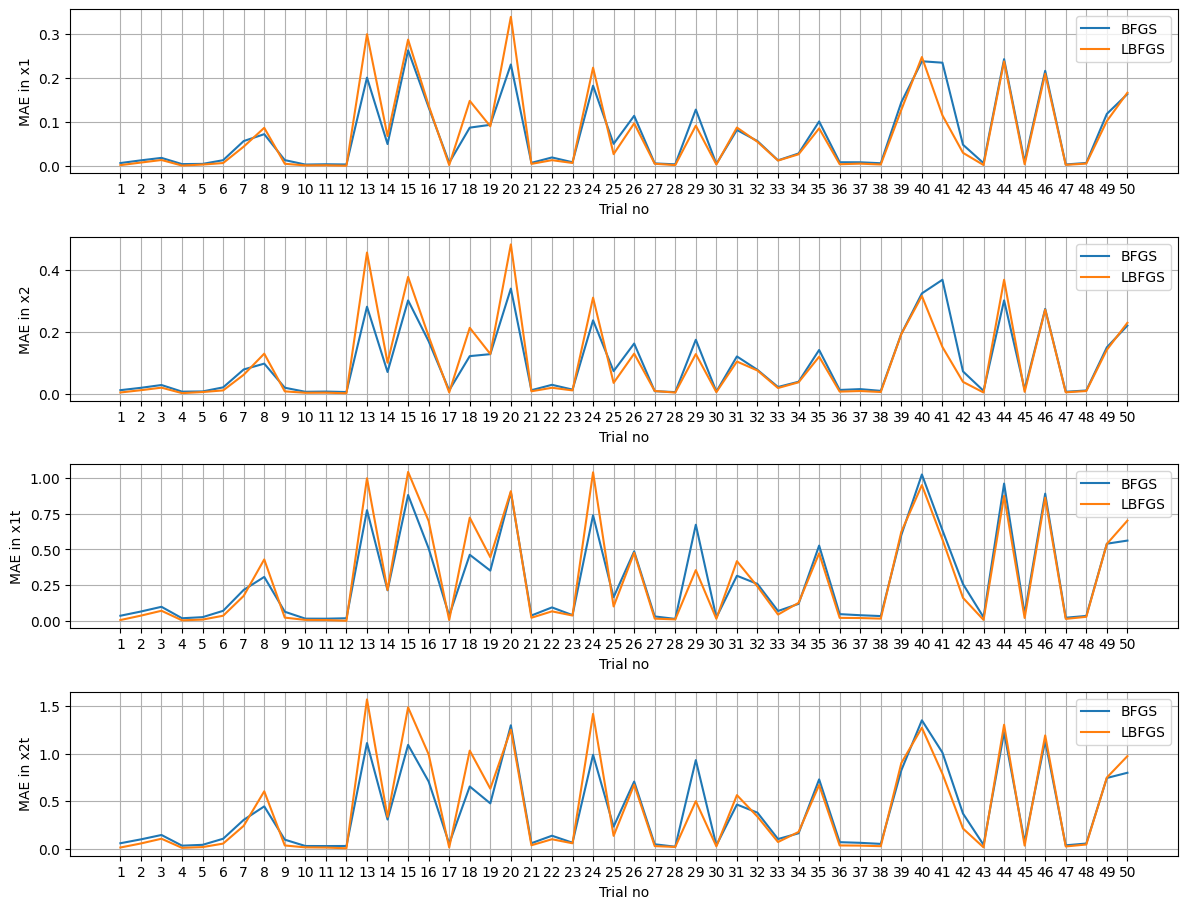

In [172]:
compare_methods(50, 10.0)

In [105]:
# _, _, Vparams_flat = flatten_pytree(Vparams)
# jnp.save("V_t1.0_1000_5000_ep_DP", Vparams_flat)

# _, _, params_flat = flatten_pytree(params)
# jnp.save("P_t1.0_1000_5000_ep_DP", params_flat)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import cos, sin

import matplotlib.animation as animation

G = grav
L1 = l1
L2 = l2
L = L1 + L2
M1 = m1
M2 = m2
t_stop = 10.0
history_len = 500


def derivs(t, state):
    dydx = np.zeros_like(state)

    dydx[0] = state[1]

    delta = state[2] - state[0]
    den1 = (M1+M2) * L1 - M2 * L1 * cos(delta) * cos(delta)
    dydx[1] = ((M2 * L1 * state[1] * state[1] * sin(delta) * cos(delta)
                + M2 * G * sin(state[2]) * cos(delta)
                + M2 * L2 * state[3] * state[3] * sin(delta)
                - (M1+M2) * G * sin(state[0]))
               / den1)

    dydx[2] = state[3]

    den2 = (L2/L1) * den1
    dydx[3] = ((- M2 * L2 * state[3] * state[3] * sin(delta) * cos(delta)
                + (M1+M2) * G * sin(state[0]) * cos(delta)
                - (M1+M2) * L1 * state[1] * state[1] * sin(delta)
                - (M1+M2) * G * sin(state[2]))
               / den2)

    return dydx

dt = 0.01
t = np.arange(0, t_stop, dt)

th1 = 120.0
w1 = 0.0
th2 = -10.0
w2 = 0.0

state = np.radians([th1, w1, th2, w2])

y = np.empty((len(t), 4))
y[0] = state
for i in range(1, len(t)):
    y[i] = y[i - 1] + derivs(t[i - 1], y[i - 1]) * dt


x1 = L1*sin(y[:, 0])
y1 = -L1*cos(y[:, 0])

x2 = L2*sin(y[:, 2]) + x1
y2 = -L2*cos(y[:, 2]) + y1

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(autoscale_on=False, xlim=(-L, L), ylim=(-L, 1.))
ax.set_aspect('equal')
ax.grid()

line, = ax.plot([], [], 'o-', lw=2)
trace, = ax.plot([], [], '.-', lw=1, ms=2)
time_template = 'time = %.1fs'
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)


def animate(i):
    thisx = [0, x1[i], x2[i]]
    thisy = [0, y1[i], y2[i]]

    history_x = x2[:i]
    history_y = y2[:i]

    line.set_data(thisx, thisy)
    trace.set_data(history_x, history_y)
    time_text.set_text(time_template % (i*dt))
    return line, trace, time_text


ani = animation.FuncAnimation(
    fig, animate, len(y), interval=dt*1000, blit=True)
plt.show()